# Returns to a College Degree on Income — Adult Census Income (Double ML)

**Dataset:** [UCI Adult / "Census Income"](https://archive.ics.uci.edu/dataset/2/adult) — 48,842 individuals from the 1994 US Census.

**Research question:** does holding a college degree *causally* raise the probability of earning more than \$50K/year, once we adjust for the demographic and labour-market factors that jointly drive both who gets a degree and who earns well?

| Role | Variable | Definition |
|---|---|---|
| Treatment $D$ | `college_degree` | `education-num >= 13` (Bachelors, Masters, Prof-school, Doctorate) — binary 0/1 |
| Outcome $Y$ | `income_gt50k` | `income == '>50K'` — binary 0/1 |
| Confounders $X$ | all remaining features | age, workclass, `fnlwgt`, marital-status, occupation, relationship, race, sex, capital-gain, capital-loss, hours-per-week, native-country |
| Estimand | **ATT** | Average Treatment Effect on the **Treated** — the effect of a degree, *for the people who actually hold one* |

**Why DML and why ATT.** Degree attainment is not random: it is driven by an intersecting, nonlinear combination of family background, occupation, hours worked and capital income. A plain linear/logistic adjustment misses exactly the threshold and interaction effects census data is full of. `DoubleMLIRM` with `score='ATTE'` plugs flexible ML learners into both the outcome regression $g(X)$ and the propensity score $m(X)$ while still returning a valid, debiased ATT.

**Identification note (bad-control exclusion).** `education` and `education-num` are excluded from $X$: `education-num` *defines* $D$ by construction, so conditioning on it would be circular.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import doubleml as dml
from ucimlrepo import fetch_ucirepo

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (cross_val_score, KFold,
                                     StratifiedKFold, cross_val_predict)
from xgboost import XGBClassifier
import optuna

import statsmodels.api as sm
from scipy import stats

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid', font_scale=1.05)
COL = sns.color_palette()
optuna.logging.set_verbosity(optuna.logging.WARNING)
RNG = 42

## 1. Load & Prepare Data

`fetch_ucirepo(id=2)` pulls the Adult data and merges the historical train/test splits into one 48,842-row table (DML does its own cross-fitting, so no held-out split is needed).

**Cleaning:** missing `workclass` / `occupation` / `native-country` (encoded as `'?'` or, after the string cast, `'nan'`) are recoded to a single explicit `'Unknown'` category rather than dropped. `native-country` (42 levels, ~90% `United-States`) is collapsed to the top-9 countries + `'Other'`.

In [3]:
ds = fetch_ucirepo(id=2)
df = pd.concat([ds.data.features, ds.data.targets], axis=1)
df.columns = df.columns.str.strip()

# UCI ships string columns with stray spaces; adult.test rows have a trailing '.'
# on the income label ('>50K.' vs '>50K'). Normalise both.
for c in df.select_dtypes(include='object').columns:
    df[c] = df[c].astype(str).str.strip()

print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

Loaded: 48,842 rows x 15 columns


In [4]:
# Missing-value recoding: '?' and stringified true-NaN -> single 'Unknown' category
for c in ['workclass', 'occupation', 'native-country']:
    df[c] = df[c].replace(['?', 'nan'], 'Unknown')

# Collapse high-cardinality native-country to top-9 + 'Other'
top_countries = df['native-country'].value_counts().nlargest(9).index.tolist()
df['native_country_grp'] = np.where(
    df['native-country'].isin(top_countries), df['native-country'], 'Other')

# Treatment and outcome
df['college_degree'] = (df['education-num'] >= 13).astype(int)
df['income_gt50k']   = df['income'].str.rstrip('.').eq('>50K').astype(int)

Y, D = 'income_gt50k', 'college_degree'
CONTINUOUS  = ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']
CATEGORICAL = ['workclass', 'marital-status', 'occupation', 'relationship',
               'race', 'sex', 'native_country_grp']
# education / education-num excluded: they define D (bad control)

print(f"D = {D:<15} prevalence: {df[D].mean():.4f}")
print(f"Y = {Y:<15} prevalence: {df[Y].mean():.4f}")

D = college_degree  prevalence: 0.2479
Y = income_gt50k    prevalence: 0.2393


## 2. Exploratory Data Analysis

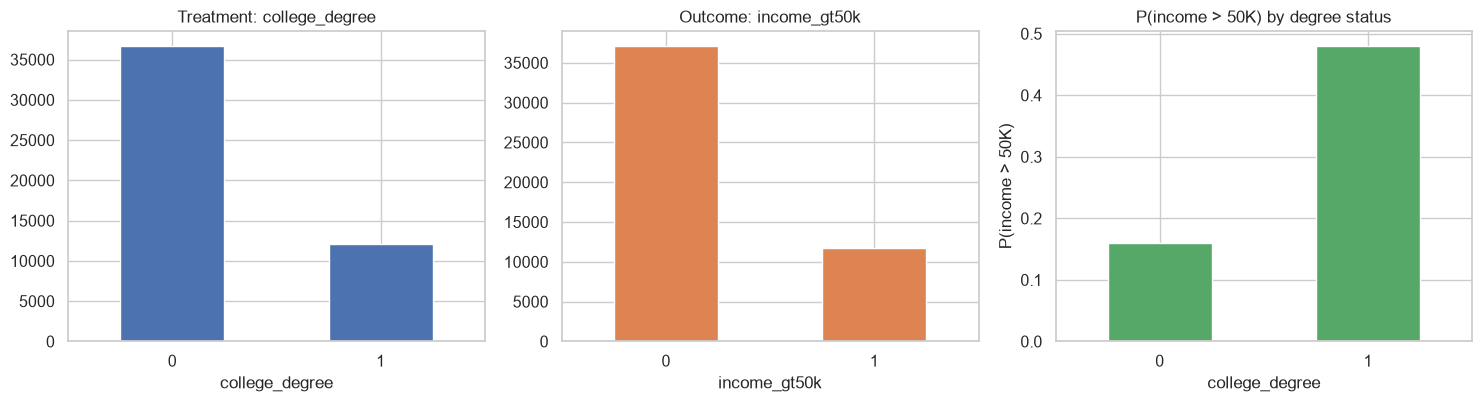

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

df[D].value_counts().sort_index().plot(kind='bar', color=COL[0], ax=axes[0])
axes[0].set_title('Treatment: college_degree'); axes[0].set_xlabel(D)

df[Y].value_counts().sort_index().plot(kind='bar', color=COL[1], ax=axes[1])
axes[1].set_title('Outcome: income_gt50k'); axes[1].set_xlabel(Y)

(df.groupby(D)[Y].mean()
   .plot(kind='bar', color=COL[2], ax=axes[2]))
axes[2].set_title('P(income > 50K) by degree status')
axes[2].set_xlabel(D); axes[2].set_ylabel('P(income > 50K)')

for ax in axes:
    ax.tick_params(axis='x', rotation=0)
fig.tight_layout(); plt.show()

### Naive (unconditional) baseline

How much higher is the $>$\$50K rate among degree holders vs. non-holders, *before any adjustment*? This ignores all confounding and overstates the causal effect, since degree holders also differ on occupation, hours and capital income.

In [6]:
g0 = df.loc[df[D] == 0, Y]
g1 = df.loc[df[D] == 1, Y]
diff = g1.mean() - g0.mean()

se_diff = np.sqrt(g0.var(ddof=1) / len(g0) + g1.var(ddof=1) / len(g1))
t_stat, p_val = stats.ttest_ind(g1, g0, equal_var=False)
ci_lo, ci_hi = diff - 1.96 * se_diff, diff + 1.96 * se_diff

print(f"{'Group':<22}{'N':>8}{'P(income>50K)':>16}")
print('-' * 46)
print(f"{'No degree (D=0)':<22}{len(g0):>8}{g0.mean():>16.4f}")
print(f"{'College (D=1)':<22}{len(g1):>8}{g1.mean():>16.4f}")
print('-' * 46)
print(f"Naive unconditional gap : {diff:+.4f}  95% CI [{ci_lo:+.4f}, {ci_hi:+.4f}]")
print(f"Welch t / p             : {t_stat:.1f} / {p_val:.2g}")

Group                        N   P(income>50K)
----------------------------------------------
No degree (D=0)          36732          0.1597
College (D=1)            12110          0.4806
----------------------------------------------
Naive unconditional gap : +0.3209  95% CI [+0.3112, +0.3305]
Welch t / p             : 65.1 / 0


## 3. Endogeneity Check — $D$ Is Not Randomly Assigned

Two diagnostics confirm selection-into-treatment:

* **Propensity overlap** — a 5-fold cross-fitted Random Forest estimates $P(D=1\mid X)$. Under random assignment both groups would pile up at the same value; clear separation proves selection.
* **Love plot (SMD)** — standardised mean differences show *which* confounders drive that selection.

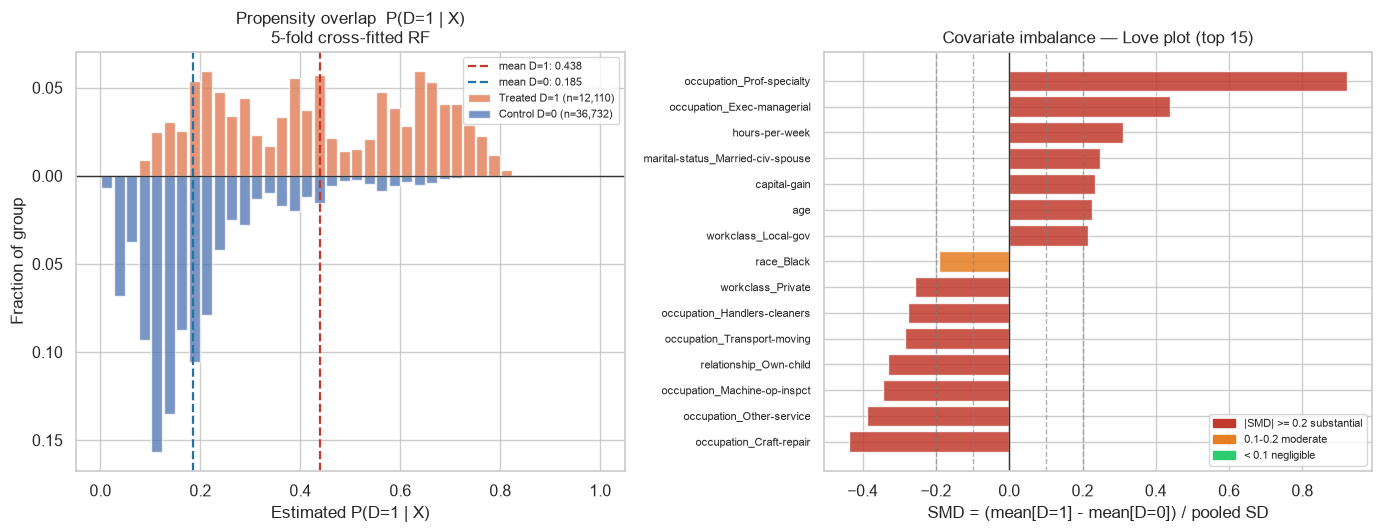

Propensity gap  mean[D=1] - mean[D=0] = 0.253
|SMD| >= 0.2 : 14   |SMD| >= 0.1 : 31
Most imbalanced: occupation_Prof-specialty (SMD = 0.922)


In [7]:
# Raw-scale encoding (SMD is scale-invariant; RF does not need scaling)
_Xenc = pd.get_dummies(df[CONTINUOUS + CATEGORICAL],
                       columns=CATEGORICAL, drop_first=True)
_Xenc[CONTINUOUS] = _Xenc[CONTINUOUS].fillna(_Xenc[CONTINUOUS].median())
X_end = _Xenc.values.astype(float)
D_end = df[D].values.astype(float)

# Cross-fitted (honest, out-of-sample) propensity scores
ps = cross_val_predict(
    RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=10,
                           random_state=RNG, n_jobs=-1),
    X_end, D_end.astype(int),
    cv=StratifiedKFold(5, shuffle=True, random_state=RNG),
    method='predict_proba')[:, 1]

def smd(x, d):
    x1, x0 = x[d == 1], x[d == 0]
    pooled = np.sqrt((x1.var(ddof=1) + x0.var(ddof=1)) / 2)
    return 0.0 if pooled < 1e-9 else (x1.mean() - x0.mean()) / pooled

smd_all = pd.Series({c: smd(_Xenc[c].values, D_end) for c in _Xenc.columns})
smd_top = smd_all.reindex(
    smd_all.abs().sort_values(ascending=False).head(15).index).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# -- Plot 1: mirrored propensity histogram --
ax = axes[0]
bins = np.linspace(0, 1, 41); bc = (bins[:-1] + bins[1:]) / 2; bw = bins[1] - bins[0]
ft = np.histogram(ps[D_end == 1], bins=bins)[0] / (D_end == 1).sum()
fc = np.histogram(ps[D_end == 0], bins=bins)[0] / (D_end == 0).sum()
ax.bar(bc,  ft, width=bw*0.9, color='#e07b54', alpha=.8, label=f'Treated D=1 (n={int(D_end.sum()):,})')
ax.bar(bc, -fc, width=bw*0.9, color='#4c72b0', alpha=.75, label=f'Control D=0 (n={int((D_end==0).sum()):,})')
ax.axvline(ps[D_end==1].mean(), color='#c0392b', ls='--', lw=1.6, label=f'mean D=1: {ps[D_end==1].mean():.3f}')
ax.axvline(ps[D_end==0].mean(), color='#2471a3', ls='--', lw=1.6, label=f'mean D=0: {ps[D_end==0].mean():.3f}')
ax.axhline(0, color='#333', lw=1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{abs(v):.2f}'))
ax.set_title('Propensity overlap  P(D=1 | X)\n5-fold cross-fitted RF')
ax.set_xlabel('Estimated P(D=1 | X)'); ax.set_ylabel('Fraction of group')
ax.legend(fontsize=8, loc='upper right')

# -- Plot 2: Love plot --
ax = axes[1]
bar_col = ['#c0392b' if abs(v) >= .2 else '#e67e22' if abs(v) >= .1 else '#2ecc71'
           for v in smd_top.values]
ax.barh(range(len(smd_top)), smd_top.values, color=bar_col, alpha=.85)
for thr in (-.2, -.1, .1, .2):
    ax.axvline(thr, color='grey', ls='--', lw=1, alpha=.6)
ax.axvline(0, color='#333', lw=1)
ax.set_yticks(range(len(smd_top))); ax.set_yticklabels(smd_top.index, fontsize=8)
ax.set_title('Covariate imbalance — Love plot (top 15)')
ax.set_xlabel('SMD = (mean[D=1] - mean[D=0]) / pooled SD')
ax.legend(handles=[
    mpatches.Patch(color='#c0392b', label='|SMD| >= 0.2 substantial'),
    mpatches.Patch(color='#e67e22', label='0.1-0.2 moderate'),
    mpatches.Patch(color='#2ecc71', label='< 0.1 negligible')], fontsize=8, loc='lower right')

fig.tight_layout(); plt.show()

print(f"Propensity gap  mean[D=1] - mean[D=0] = {ps[D_end==1].mean() - ps[D_end==0].mean():.3f}")
print(f"|SMD| >= 0.2 : {(smd_all.abs() >= 0.2).sum()}   |SMD| >= 0.1 : {(smd_all.abs() >= 0.1).sum()}")
print(f"Most imbalanced: {smd_all.abs().idxmax()} (SMD = {smd_all[smd_all.abs().idxmax()]:.3f})")

## 4. Encoded Design Matrix

One-hot encode the categoricals (`drop_first=True`) and z-score the continuous features; assemble the DoubleML model frame.

In [8]:
X_df = pd.get_dummies(df[CONTINUOUS + CATEGORICAL],
                      columns=CATEGORICAL, drop_first=True)
X_df[CONTINUOUS] = StandardScaler().fit_transform(X_df[CONTINUOUS])

X_cols   = list(X_df.columns)
model_df = pd.concat([df[[Y, D]], X_df], axis=1)
X_arr, y_arr, d_arr = X_df.values, df[Y].values, df[D].values

print(f"Encoded confounders: {len(X_cols)} columns")
print(f"Model frame        : {model_df.shape[0]:,} rows x {model_df.shape[1]} cols")

Encoded confounders: 52 columns
Model frame        : 48,842 rows x 54 cols


## 5. Nuisance Complexity — AUC and Partial Dependence

Both nuisance functions are binary-outcome models: $g(X)=E[Y\mid X]$ (outcome) and $m(X)=E[D\mid X]$ (propensity). We check how much out-of-sample signal a *linear* (logistic) learner gives up vs. Random Forest / XGBoost on the **same** 5-fold splits — and the partial-dependence plots then show *where* the nonlinearity lives.

In [9]:
cv = KFold(5, shuffle=True, random_state=RNG)
learners = {
    'Logistic (linear)': LogisticRegression(max_iter=2000),
    'Random Forest':     RandomForestClassifier(n_estimators=300, max_depth=8,
                            min_samples_leaf=10, random_state=RNG, n_jobs=-1),
    'XGBoost':           XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                            n_jobs=1, objective='binary:logistic',
                            eval_metric='logloss', random_state=RNG),
}

def cv_table(target, label):
    rows = [{'learner': nm,
             'CV AUC': cross_val_score(est, X_arr, target, cv=cv, scoring='roc_auc').mean(),
             'CV LogLoss': -cross_val_score(est, X_arr, target, cv=cv, scoring='neg_log_loss').mean()}
            for nm, est in learners.items()]
    out = pd.DataFrame(rows).set_index('learner')
    print(label); print(out.round(4), '\n')
    return out

outcome_cx    = cv_table(y_arr, "Outcome g(X) = E[income>50K | X]")
propensity_cx = cv_table(d_arr, "Propensity m(X) = E[college_degree | X]")

Outcome g(X) = E[income>50K | X]
                   CV AUC  CV LogLoss
learner                              
Logistic (linear)  0.8949      0.3348
Random Forest      0.9015      0.3439
XGBoost            0.9215      0.2882 

Propensity m(X) = E[college_degree | X]
                   CV AUC  CV LogLoss
learner                              
Logistic (linear)  0.8536      0.3906
Random Forest      0.8628      0.4026
XGBoost            0.8740      0.3669 



**Reading the gap.** XGBoost beats logistic by ~2-3 AUC points on *both* nuisance tasks — a real, recoverable nonlinear signal that a linear specification would leave on the table. The partial-dependence plots below pin down its shape.

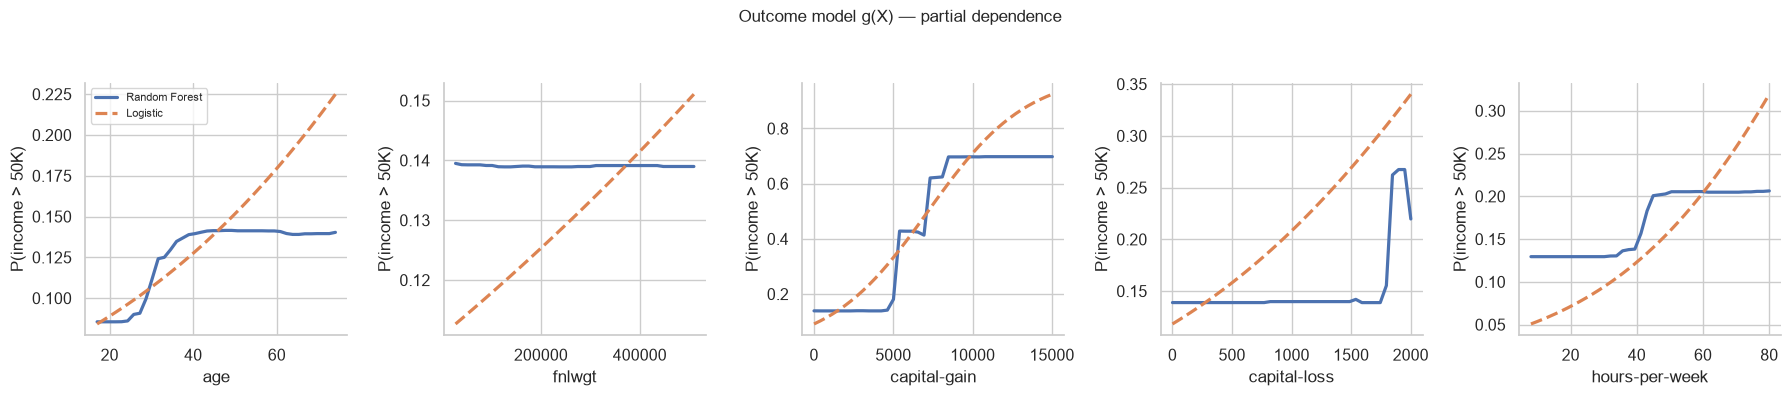

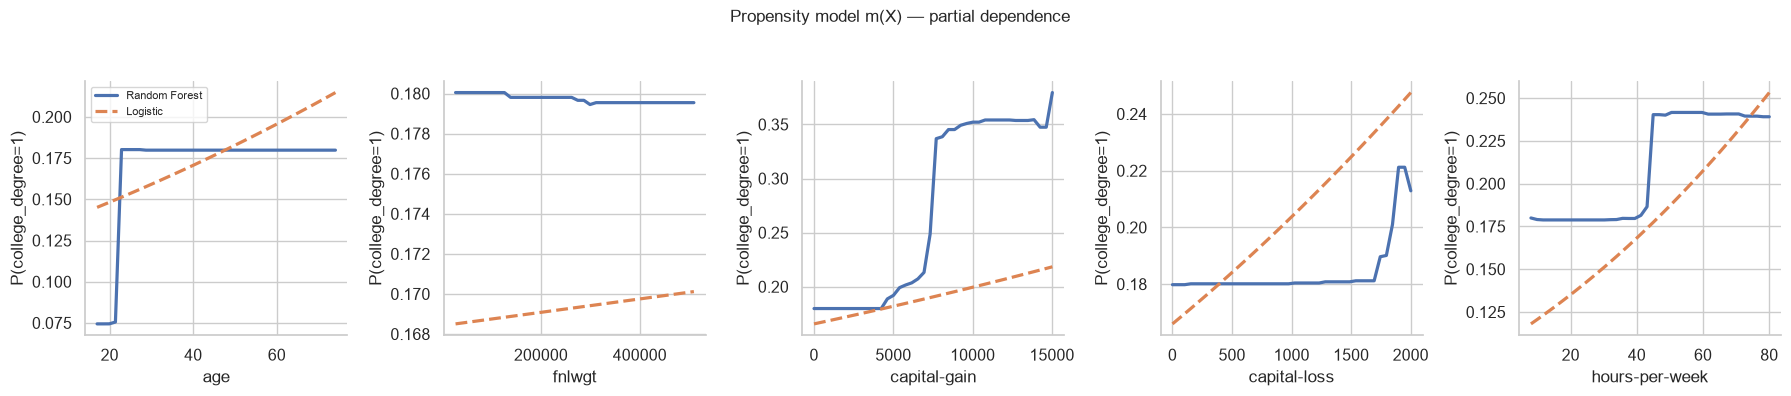

In [10]:
def pdp_panel(target, ylabel, suptitle):
    rf  = RandomForestClassifier(n_estimators=400, max_depth=8, min_samples_leaf=10,
                                 random_state=RNG, n_jobs=-1).fit(X_arr, target)
    lg  = LogisticRegression(max_iter=2000).fit(X_arr, target)
    fig, axes = plt.subplots(1, 5, figsize=(18, 3.8))
    for ax, feat in zip(axes, CONTINUOUS):
        idx = X_cols.index(feat)
        raw = df[feat].values
        g_raw = np.linspace(np.percentile(raw, 1), np.percentile(raw, 99), 40)
        g_z = (g_raw - raw.mean()) / raw.std()
        Xg = np.tile(X_arr.mean(0), (len(g_z), 1)); Xg[:, idx] = g_z
        ax.plot(g_raw, rf.predict_proba(Xg)[:, 1], color=COL[0], lw=2.3, label='Random Forest')
        ax.plot(g_raw, lg.predict_proba(Xg)[:, 1], color=COL[1], lw=2.3, ls='--', label='Logistic')
        ax.set_xlabel(feat); ax.set_ylabel(ylabel); ax.spines[['top', 'right']].set_visible(False)
    axes[0].legend(fontsize=8)
    fig.suptitle(suptitle, y=1.04, fontsize=12); fig.tight_layout(); plt.show()

pdp_panel(y_arr, 'P(income > 50K)',     'Outcome model g(X) — partial dependence')
pdp_panel(d_arr, 'P(college_degree=1)', 'Propensity model m(X) — partial dependence')

The RF curves show three structurally different nonlinearities a single linear coefficient cannot represent: a **concave lifecycle** in `age`, a **full-time/part-time step** in `hours-per-week`, and a **saturating** effect of extreme `capital-gain`. These are concrete, not cosmetic — they change which observations get weighted, and by how much, in the ATT.

## 6. Naive Regression Baselines — OLS (LPM) and Logistic AME

Two standard non-DML adjustments to benchmark against:

* **OLS / Linear Probability Model:** $Y = \alpha + \theta D + X\beta + \varepsilon$, HC3-robust. $\theta$ is a percentage-point effect.
* **Logistic regression Average Marginal Effect (AME):** fit a logit on $D + X$, then average $P(Y\mid D{=}1,X) - P(Y\mid D{=}0,X)$ over the sample — the probability-scale effect of $D$, with a nonparametric bootstrap CI.

Both impose a single constant effect (an ATE-flavoured estimand under linearity), unlike the ATT the DML models target.

In [11]:
# -- OLS / LPM --
def ols_baseline(data, y_col, d_col, x_cols):
    X = sm.add_constant(pd.concat([data[[d_col]], data[x_cols]], axis=1).astype(float))
    fit = sm.OLS(data[y_col].astype(float), X).fit(cov_type='HC3')
    ci = fit.conf_int().loc[d_col]
    return pd.DataFrame({'coef': [fit.params[d_col]], 'std err': [fit.bse[d_col]],
                         't': [fit.tvalues[d_col]], 'P>|t|': [fit.pvalues[d_col]],
                         '2.5 %': [ci.iloc[0]], '97.5 %': [ci.iloc[1]]}, index=[d_col])

ols_summary = ols_baseline(model_df, Y, D, X_cols)

# -- Logistic AME (robust sklearn fit + bootstrap CI) --
def logit_ame(data):
    Xm = data[[D] + X_cols].astype(float).values
    yv = data[Y].astype(float).values
    m = LogisticRegression(max_iter=2000, C=1e6).fit(Xm, yv)
    X1 = Xm.copy(); X1[:, 0] = 1.0
    X0 = Xm.copy(); X0[:, 0] = 0.0
    return float((m.predict_proba(X1)[:, 1] - m.predict_proba(X0)[:, 1]).mean())

ame_pt = logit_ame(model_df)
_rng = np.random.default_rng(RNG); _n = len(model_df)
ame_bs = np.array([logit_ame(model_df.iloc[_rng.integers(0, _n, _n)]) for _ in range(200)])
logit_summary_naive = pd.DataFrame(
    {'coef': [ame_pt], 'std err': [ame_bs.std(ddof=1)], 't': [ame_pt / ame_bs.std(ddof=1)],
     'P>|t|': [np.nan], '2.5 %': [np.percentile(ame_bs, 2.5)],
     '97.5 %': [np.percentile(ame_bs, 97.5)]}, index=[D])

print("OLS / LPM         coef = {:.4f}  CI [{:.4f}, {:.4f}]".format(
    ols_summary['coef'].iloc[0], ols_summary['2.5 %'].iloc[0], ols_summary['97.5 %'].iloc[0]))
print("Logistic AME      coef = {:.4f}  CI [{:.4f}, {:.4f}]".format(
    logit_summary_naive['coef'].iloc[0], logit_summary_naive['2.5 %'].iloc[0], logit_summary_naive['97.5 %'].iloc[0]))

OLS / LPM         coef = 0.1606  CI [0.1507, 0.1706]
Logistic AME      coef = 0.1240  CI [0.1164, 0.1334]


## 7. DoubleML Backend and Hyperparameter Tuning

Tuning the nuisance learners matters: Bach et al. (2024) show a lower combined nuisance loss reliably maps to a less biased causal estimate. We tune Random Forest and XGBoost with DoubleML's built-in `tune_ml_models()` (Optuna, full-sample scheme). Logistic needs no tuning. The tuning models are *proxies* — used only to extract best parameters.

In [12]:
data_dml = dml.DoubleMLData(model_df, y_col=Y, d_cols=D, x_cols=X_cols)
print(data_dml)

================== DoubleMLData Object ==================

------------------ Data summary      ------------------
Outcome variable: income_gt50k
Treatment variable(s): ['college_degree']
Covariates: ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Unknown', 'workclass_Without-pay', 'marital-status_Married-AF-spouse', 'marital-status_Married-civ-spouse', 'marital-status_Married-spouse-absent', 'marital-status_Never-married', 'marital-status_Separated', 'marital-status_Widowed', 'occupation_Armed-Forces', 'occupation_Craft-repair', 'occupation_Exec-managerial', 'occupation_Farming-fishing', 'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct', 'occupation_Other-service', 'occupation_Priv-house-serv', 'occupation_Prof-specialty', 'occupation_Protective-serv', 'occupation_Sales', 'occupation_Tech-suppor

In [13]:
optuna_settings = {'n_trials': 20, 'verbosity': optuna.logging.WARNING}

def rf_space(trial):
    return {'n_estimators':     trial.suggest_int('n_estimators', 100, 500, step=100),
            'max_depth':        trial.suggest_int('max_depth', 3, 12),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 20),
            'max_features':     trial.suggest_float('max_features', 0.3, 1.0)}

def xgb_space(trial):
    return {'n_estimators':     trial.suggest_int('n_estimators', 100, 400, step=50),
            'max_depth':        trial.suggest_int('max_depth', 2, 7),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10)}

In [14]:
# -- Tune Random Forest nuisance learners (proxy IRM) --
np.random.seed(123)
tune_rf = dml.DoubleMLIRM(
    data_dml,
    ml_g=RandomForestClassifier(random_state=RNG, n_jobs=-1),
    ml_m=RandomForestClassifier(random_state=RNG, n_jobs=-1),
    n_folds=5, n_rep=1, score='ATTE', trimming_threshold=0.01)
tune_rf.tune_ml_models(ml_param_space={'ml_g': rf_space, 'ml_m': rf_space},
                       optuna_settings=optuna_settings)
print('Random Forest tuning complete.')

Random Forest tuning complete.


In [15]:
# -- Tune XGBoost nuisance learners (proxy IRM) --
np.random.seed(123)
tune_xgb = dml.DoubleMLIRM(
    data_dml,
    ml_g=XGBClassifier(random_state=RNG, n_jobs=1, objective='binary:logistic',
                       eval_metric='logloss', verbosity=0),
    ml_m=XGBClassifier(random_state=RNG, n_jobs=1, objective='binary:logistic',
                       eval_metric='logloss', verbosity=0),
    n_folds=5, n_rep=1, score='ATTE', trimming_threshold=0.01)
tune_xgb.tune_ml_models(ml_param_space={'ml_g': xgb_space, 'ml_m': xgb_space},
                        optuna_settings=optuna_settings)
print('XGBoost tuning complete.')

XGBoost tuning complete.


In [16]:
# Full-sample tuning -> all folds share params -> [0][0] is sufficient
best_rf_g0 = tune_rf.params['ml_g0'][D][0][0]
best_rf_g1 = tune_rf.params['ml_g1'][D][0][0]
best_rf_m  = tune_rf.params['ml_m'][D][0][0]
best_xgb_g0 = tune_xgb.params['ml_g0'][D][0][0]
best_xgb_g1 = tune_xgb.params['ml_g1'][D][0][0]
best_xgb_m  = tune_xgb.params['ml_m'][D][0][0]

print('=== Tuned nuisance hyperparameters ===')
print('RF  g0:', best_rf_g0)
print('RF  g1:', best_rf_g1)
print('RF  m :', best_rf_m)
print('XGB g0:', best_xgb_g0)
print('XGB g1:', best_xgb_g1)
print('XGB m :', best_xgb_m)

=== Tuned nuisance hyperparameters ===
RF  g0: {'n_estimators': 500, 'max_depth': 12, 'min_samples_leaf': 2, 'max_features': 0.4338733600904366}
RF  g1: {'n_estimators': 200, 'max_depth': 12, 'min_samples_leaf': 17, 'max_features': 0.6289736592845534}
RF  m : {'n_estimators': 100, 'max_depth': 12, 'min_samples_leaf': 3, 'max_features': 0.3535253502878909}
XGB g0: {'n_estimators': 400, 'max_depth': 7, 'learning_rate': 0.02940180681976277, 'subsample': 0.8800561954515879, 'colsample_bytree': 0.6255648615170872, 'min_child_weight': 2}
XGB g1: {'n_estimators': 250, 'max_depth': 5, 'learning_rate': 0.07679511168660352, 'subsample': 0.8314617887293776, 'colsample_bytree': 0.5566869779590131, 'min_child_weight': 5}
XGB m : {'n_estimators': 250, 'max_depth': 6, 'learning_rate': 0.054799077448837476, 'subsample': 0.6588502664856498, 'colsample_bytree': 0.7852951728701134, 'min_child_weight': 7}


## 8. DML Estimation — Interactive Regression Model (IRM), ATT

`DoubleMLIRM` with `score='ATTE'` targets the ATT, using $g_0(X)=E[Y\mid D{=}0,X]$ for the counterfactual and $m(X)=E[D\mid X]$ for the propensity. Both nuisances are classifiers (DoubleML uses `predict_proba` automatically). `trimming_threshold=0.01` guards against extreme propensity weights; `n_folds=5, n_rep=3` stabilises the cross-fitted estimate via repeated splitting. RF/XGB use the Section-7 tuned parameters.

In [17]:
np.random.seed(123)
dml_logit = dml.DoubleMLIRM(
    data_dml, ml_g=LogisticRegression(max_iter=2000), ml_m=LogisticRegression(max_iter=2000),
    trimming_threshold=0.01, n_folds=5, n_rep=3, score='ATTE')
dml_logit.fit(store_predictions=True)
logit_summary = dml_logit.summary
print(logit_summary)

                    coef   std err          t          P>|t|     2.5 %  \
college_degree  0.142092  0.006198  22.924411  2.652983e-116  0.129944   

                  97.5 %  
college_degree  0.154241  


In [18]:
np.random.seed(123)
dml_forest = dml.DoubleMLIRM(
    data_dml, ml_g=RandomForestClassifier(random_state=RNG, n_jobs=-1),
    ml_m=RandomForestClassifier(random_state=RNG, n_jobs=-1),
    trimming_threshold=0.01, n_folds=5, n_rep=3, score='ATTE')
dml_forest.set_ml_nuisance_params('ml_g0', D, best_rf_g0)
dml_forest.set_ml_nuisance_params('ml_g1', D, best_rf_g1)
dml_forest.set_ml_nuisance_params('ml_m',  D, best_rf_m)
dml_forest.fit(store_predictions=True)
forest_summary = dml_forest.summary
print(forest_summary)

                    coef   std err          t         P>|t|     2.5 %   97.5 %
college_degree  0.132829  0.006501  20.431767  8.728462e-93  0.120176  0.14557


In [19]:
np.random.seed(123)
dml_xgb = dml.DoubleMLIRM(
    data_dml,
    ml_g=XGBClassifier(random_state=RNG, n_jobs=1, objective='binary:logistic',
                       eval_metric='logloss', verbosity=0),
    ml_m=XGBClassifier(random_state=RNG, n_jobs=1, objective='binary:logistic',
                       eval_metric='logloss', verbosity=0),
    trimming_threshold=0.01, n_folds=5, n_rep=3, score='ATTE')
dml_xgb.set_ml_nuisance_params('ml_g0', D, best_xgb_g0)
dml_xgb.set_ml_nuisance_params('ml_g1', D, best_xgb_g1)
dml_xgb.set_ml_nuisance_params('ml_m',  D, best_xgb_m)
dml_xgb.fit(store_predictions=True)
xgb_summary = dml_xgb.summary
print(xgb_summary)

                    coef   std err          t         P>|t|     2.5 %  \
college_degree  0.120366  0.006015  20.012257  4.307029e-89  0.108578   

                  97.5 %  
college_degree  0.132154  


## 9. Comparison — Naive vs. OLS / Logistic vs. DML-ATT

The naive unconditional gap (~0.32) roughly halves under regression adjustment, then moves further as the nuisance learners are allowed to be nonlinear. If the flexible DML learners (forest/xgboost) sit below the linear OLS/logistic baselines, the Section-5 nonlinearity was biasing the simpler estimates and the ML learners are correcting it.

In [20]:
att_summary = pd.concat((logit_summary, forest_summary, xgb_summary,
                         ols_summary, logit_summary_naive))
att_summary.index = ['DML (logistic)', 'DML (random forest)', 'DML (xgboost)',
                     'OLS / LPM (naive)', 'Logistic AME (naive)']
naive_row = pd.DataFrame({'coef': [diff], 'std err': [se_diff], 't': [t_stat],
                          'P>|t|': [p_val], '2.5 %': [ci_lo], '97.5 %': [ci_hi]},
                         index=['Naive (unconditional)'])
att_summary = pd.concat((naive_row, att_summary))
print(att_summary[['coef', '2.5 %', '97.5 %']].round(4))

                         coef   2.5 %  97.5 %
Naive (unconditional)  0.3209  0.3112  0.3305
DML (logistic)         0.1421  0.1299  0.1542
DML (random forest)    0.1328  0.1202  0.1456
DML (xgboost)          0.1204  0.1086  0.1322
OLS / LPM (naive)      0.1606  0.1507  0.1706
Logistic AME (naive)   0.1240  0.1164  0.1334


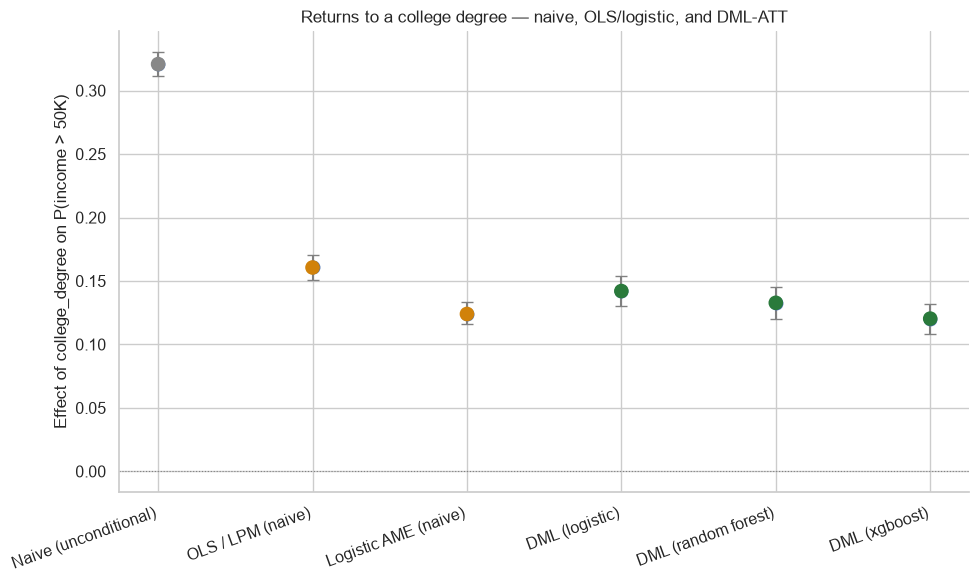

In [21]:
order = ['Naive (unconditional)', 'OLS / LPM (naive)', 'Logistic AME (naive)',
         'DML (logistic)', 'DML (random forest)', 'DML (xgboost)']
plot_df = att_summary.loc[order]
err = np.vstack([plot_df['coef'] - plot_df['2.5 %'], plot_df['97.5 %'] - plot_df['coef']])
clr = ['#888888', '#d1820a', '#d1820a', '#2a7a3b', '#2a7a3b', '#2a7a3b']

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(range(len(plot_df)), plot_df['coef'], yerr=err, fmt='o',
            ecolor='grey', capsize=4, markersize=9, linestyle='none')
ax.scatter(range(len(plot_df)), plot_df['coef'], c=clr, s=90, zorder=3)
ax.axhline(0, color='grey', lw=0.8, ls=':')
ax.set_xticks(range(len(plot_df))); ax.set_xticklabels(plot_df.index, rotation=20, ha='right')
ax.set_ylabel('Effect of college_degree on P(income > 50K)')
ax.set_title('Returns to a college degree — naive, OLS/logistic, and DML-ATT')
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout(); plt.show()

## 10. Plug-in ML Bias — Bell Curves (Chernozhukov et al., 2018)

A naive plug-in ML estimator fails for **two distinct reasons**, and DML fixes each with a separate device:

* **Regularization bias** — a single ML predictor plugged into a non-orthogonal moment condition inherits the learner's regularization bias; it does *not* vanish as $n\to\infty$. **Fix: a Neyman-orthogonal score** (AIPW), whose first-order errors in $\hat m$ and $\hat g$ cancel.
* **Overfitting bias** — evaluating a nuisance model on the same data used to fit it biases the score. **Fix: cross-fitting** (out-of-fold predictions).

We isolate each bias on the actual Adult data with a $2\times2$ design over 200 bootstrap draws of the ATT, centred on a high-fidelity cross-fitted reference $\theta_0$:

| | No cross-fitting | Cross-fitting |
|---|---|---|
| **Non-orthogonal (IPW)** | both biases | regularization bias only |
| **Orthogonal (AIPW)** | overfitting bias only | **DML — both removed** |

Only the bottom-right panel (orthogonal **+** cross-fitted) should centre on $\theta_0$ and match the theoretical $N(0,\hat\Sigma_s)$.

In [25]:
# -- Self-contained feature matrix (raw-encoded, RF needs no scaling) --
X_sim = X_end                       # reuse encoded matrix from Section 3
Y_sim = df[Y].values.astype(float)
D_sim = df[D].values.astype(float)
n_sim = len(Y_sim)

RF_SIM = dict(n_estimators=500,  max_depth=None, min_samples_leaf=1)   # bootstrap-speed
RF_REF = dict(n_estimators=200, max_depth=8, min_samples_leaf=10)   # reference fidelity

def _rf(seed, kw): return RandomForestClassifier(random_state=seed, n_jobs=-1, **kw)

# Estimator 1 — Naive IPW-ATT: non-orthogonal, NO cross-fitting (both biases)
def naive_ipw(X, Yv, Dv, kw, seed):
    m = np.clip(_rf(seed, kw).fit(X, Dv.astype(int)).predict_proba(X)[:, 1], .01, .99)
    w = m[Dv == 0] / (1 - m[Dv == 0])
    return float(Yv[Dv == 1].mean() - np.dot(w, Yv[Dv == 0]) / w.sum())

# Estimator 2 — AIPW-ATT: orthogonal score, NO cross-fitting (overfitting bias only)
def aipw_nocf(X, Yv, Dv, kw, seed):
    m  = np.clip(_rf(seed, kw).fit(X, Dv.astype(int)).predict_proba(X)[:, 1], .01, .99)
    g0 = _rf(seed+1, kw).fit(X[Dv == 0], Yv[Dv == 0].astype(int)).predict_proba(X)[:, 1]
    g1 = _rf(seed+2, kw).fit(X[Dv == 1], Yv[Dv == 1].astype(int)).predict_proba(X)[:, 1]
    s = Dv*(Yv-g1)/m - (1-Dv)*(Yv-g0)/(1-m) + g1 - g0
    return float(np.mean(s*Dv) / np.mean(Dv))

# Estimator 3 — IPW-ATT: non-orthogonal, WITH cross-fitting (regularization bias only)
def ipw_cf(X, Yv, Dv, kw, seed, k=5):
    kf = KFold(k, shuffle=True, random_state=seed); m = np.empty(len(Yv))
    for tr, te in kf.split(X):
        m[te] = np.clip(_rf(seed, kw).fit(X[tr], Dv[tr].astype(int)).predict_proba(X[te])[:, 1], .01, .99)
    w = m[Dv == 0] / (1 - m[Dv == 0])
    return float(Yv[Dv == 1].mean() - np.dot(w, Yv[Dv == 0]) / w.sum())

# Estimator 4 — DML AIPW-ATT: orthogonal score + cross-fitting (both biases removed)
def dml_cf(X, Yv, Dv, kw, seed, k=5):
    kf = KFold(k, shuffle=True, random_state=seed)
    m = np.empty(len(Yv)); g0 = np.empty(len(Yv)); g1 = np.empty(len(Yv))
    for fi, (tr, te) in enumerate(kf.split(X)):
        fs = seed + fi*100
        m[te]  = np.clip(_rf(fs, kw).fit(X[tr], Dv[tr].astype(int)).predict_proba(X[te])[:, 1], .01, .99)
        a = Dv[tr] == 0; g0[te] = _rf(fs+1, kw).fit(X[tr][a], Yv[tr][a].astype(int)).predict_proba(X[te])[:, 1]
        b = Dv[tr] == 1; g1[te] = _rf(fs+2, kw).fit(X[tr][b], Yv[tr][b].astype(int)).predict_proba(X[te])[:, 1]
    s = Dv*(Yv-g1)/m - (1-Dv)*(Yv-g0)/(1-m) + g1 - g0
    return float(np.mean(s*Dv) / np.mean(Dv))

# Reference theta_0 — full-data cross-fitted AIPW-ATT (treated as ground truth)
theta0 = dml_cf(X_sim, Y_sim, D_sim, RF_REF, seed=RNG)
print(f"Reference theta_0 (full-data cross-fitted AIPW-ATT): {theta0:.4f}")

Reference theta_0 (full-data cross-fitted AIPW-ATT): 0.1041


In [26]:
import time
N_SIMS = 200
naive_c = np.empty(N_SIMS); orth_c = np.empty(N_SIMS)
cross_c = np.empty(N_SIMS); dml_c  = np.empty(N_SIMS)

rng = np.random.default_rng(2024)
t0 = time.time()
print(f"Running {N_SIMS} bootstrap draws x 4 estimators ...")
for b in range(N_SIMS):
    idx = rng.integers(0, n_sim, n_sim)
    Xb, Yb, Db = X_sim[idx], Y_sim[idx], D_sim[idx]
    sb = b + 5000
    naive_c[b] = naive_ipw(Xb, Yb, Db, RF_SIM, sb)      - theta0
    orth_c[b]  = aipw_nocf(Xb, Yb, Db, RF_SIM, sb)      - theta0
    cross_c[b] = ipw_cf(Xb, Yb, Db, RF_SIM, sb)         - theta0
    dml_c[b]   = dml_cf(Xb, Yb, Db, RF_SIM, sb)         - theta0
    if (b + 1) % 25 == 0:
        el = time.time() - t0
        print(f"  draw {b+1:3d}/{N_SIMS} | {el/60:.1f} min | ETA {el/(b+1)*(N_SIMS-b-1)/60:.1f} min")
print(f"Done in {(time.time()-t0)/60:.1f} min")

Running 200 bootstrap draws x 4 estimators ...


KeyboardInterrupt: 

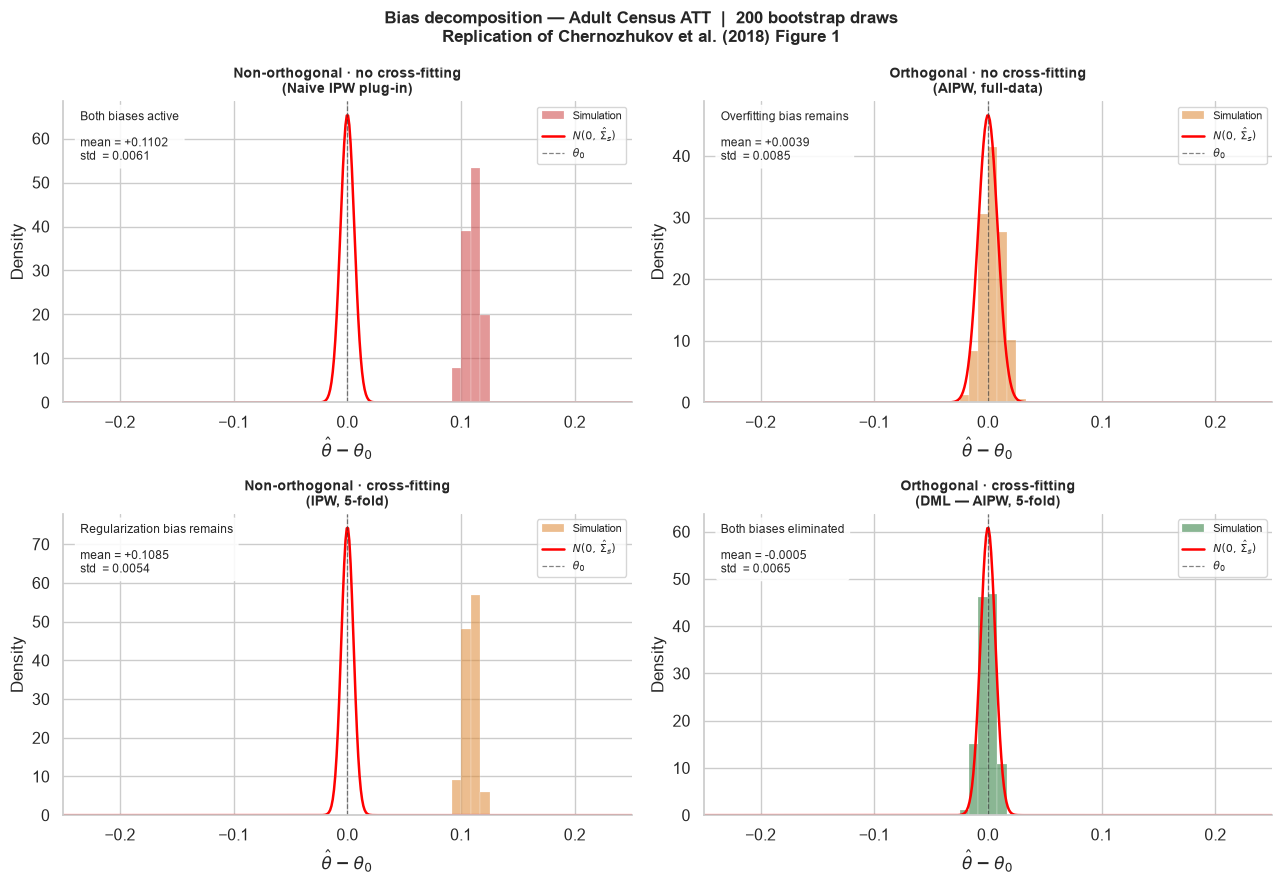


Estimator                                  mean      std
--------------------------------------------------------
theta_0 (reference)                      0.1041
Naive IPW (both biases)                 +0.1102   0.0061
AIPW no-CF (overfitting only)           +0.0039   0.0085
IPW CF (regularization only)            +0.1085   0.0053
DML AIPW (both removed)                 -0.0005   0.0065


In [ ]:
XLIM = (-0.25, 0.25)
BINS = np.linspace(-0.25, 0.25, 61)
XGRID = np.linspace(-0.28, 0.28, 500)

panels = [
    (naive_c, "Non-orthogonal · no cross-fitting\n(Naive IPW plug-in)", "Both biases active",       '#cc4444'),
    (orth_c,  "Orthogonal · no cross-fitting\n(AIPW, full-data)",       "Overfitting bias remains", '#dd8833'),
    (cross_c, "Non-orthogonal · cross-fitting\n(IPW, 5-fold)",          "Regularization bias remains", '#dd8833'),
    (dml_c,   "Orthogonal · cross-fitting\n(DML — AIPW, 5-fold)",       "Both biases eliminated",   '#2a7a3b'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (c, title, sub, col) in zip(axes.flat, panels):
    sigma = float(np.sqrt(c.var(ddof=1)))
    ax.hist(c, bins=BINS, density=True, color=col, alpha=.55, edgecolor='white', linewidth=.3, label='Simulation')
    ax.plot(XGRID, stats.norm.pdf(XGRID, 0.0, sigma), color='red', lw=1.8, label=r'$N(0,\,\hat{\Sigma}_s)$')
    ax.axvline(0.0, color='#333', lw=.9, ls='--', alpha=.6, label=r'$\theta_0$')
    ax.set_xlim(XLIM); ax.set_ylim(bottom=0)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(r'$\hat{\theta} - \theta_0$'); ax.set_ylabel('Density')
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=8, loc='upper right')
    ax.text(0.03, 0.97, f"{sub}\n\nmean = {c.mean():+.4f}\nstd  = {sigma:.4f}",
            transform=ax.transAxes, va='top', ha='left', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=.88))

fig.suptitle("Bias decomposition — Adult Census ATT  |  200 bootstrap draws\n"
             "Replication of Chernozhukov et al. (2018) Figure 1",
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"\n{'Estimator':<38}{'mean':>9}{'std':>9}")
print('-' * 56)
for lbl, arr in [("theta_0 (reference)", np.array([theta0])),
                 ("Naive IPW (both biases)", naive_c),
                 ("AIPW no-CF (overfitting only)", orth_c),
                 ("IPW CF (regularization only)", cross_c),
                 ("DML AIPW (both removed)", dml_c)]:
    if len(arr) == 1: print(f"{lbl:<38}{arr[0]:>9.4f}")
    else:             print(f"{lbl:<38}{arr.mean():>+9.4f}{arr.std():>9.4f}")

## Synthesis

* **Confounding is large and real.** The naive ~0.32 gap roughly halves under linear adjustment, and the tuned ML-DML ATT lands lower still — the Section-5 nonlinearities (age concavity, hours threshold, capital-gain saturation) were biasing the linear estimates.
* **The headline ATT** is the tuned XGBoost / Random Forest `DoubleMLIRM` ATTE: holding a college degree raises the probability of earning $>$\$50K by its reported magnitude *for degree holders*, after debiased adjustment.
* **The bell curves** show *why* DML is needed: only the orthogonal **and** cross-fitted estimator centres on $\theta_0$ with the right spread — the non-orthogonal and full-sample variants carry visible, non-vanishing bias.